# UGA Grad Survivor — Balance Simulation v0.8

96,000-run Monte Carlo. Mirrors JS engine mechanics after the v0.8 balance patch.

**Original `simulation.ipynb` (v0.4 baseline) is preserved unchanged.**

Sync discipline: when engine mechanics change, update the engine cell (cell 2) before re-running.

## 1. Setup & Data Load

In [1]:
import random, math, re, json, os, sys
from collections import Counter
import pandas as pd
import numpy as np
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_PLT = True
except ImportError:
    HAS_PLT = False

JS_DATA_DIR = os.path.join('..', 'js', 'data')

def pjs(s):
    s = re.sub(r'//.*?$', '', s, flags=re.MULTILINE)
    s = re.sub(r'/\*.*?\*/', '', s, flags=re.DOTALL)
    r = []; ins = False; sc = None; i = 0
    while i < len(s):
        c = s[i]
        if not ins:
            if c in '"\'': ins = True; sc = c; r.append('"')
            else: r.append(c)
        else:
            if c == '\\' and i+1 < len(s):
                nc = s[i+1]
                if sc == "'" and nc == "'": r.append("'"); i += 2; continue
                if sc == "'" and nc == '"': r.append('\\"'); i += 2; continue
                r.append(c); r.append(nc); i += 2; continue
            elif c == sc: ins = False; r.append('"')
            elif c == '"' and sc == "'": r.append('\\"')
            else: r.append(c)
        i += 1
    s = ''.join(r)
    s = re.sub(r'(?<=[{,\n])\s*([a-zA-Z_]\w*)\s*:', r' "\1":', s)
    s = re.sub(r':\s*\+(\d)', r': \1', s)
    s = re.sub(r',\s*([}\]])', r'\1', s)
    s = re.sub(r'Math\.\w+\([^)]*\)', '0', s)
    return json.loads(s)

def la(v, f): return pjs(re.search(rf'(?:const|let|var)\s+{v}\s*=\s*(\[[\s\S]*?\]);', open(os.path.join(JS_DATA_DIR, f)).read()).group(1))
def ld(v, f): return pjs(re.search(rf'(?:const|let|var)\s+{v}\s*=\s*(\{{[\s\S]*?\}});', open(os.path.join(JS_DATA_DIR, f)).read()).group(1))

ARCH = ld('ARCHETYPE_DATA', 'archetypes.js')
PI   = ld('PI_DATA', 'pi-data.js')
P1   = la('PHASE1_CARDS',    'cards-phase1.js')
P2   = la('PHASE2_CARDS',    'cards-phase2.js')
P3   = la('PHASE3_CARDS',    'cards-phase3.js')
UN   = la('UNIVERSAL_CARDS', 'cards-universal.js')
CB   = la('CALLBACK_CARDS',  'cards-callback.js')
MS   = la('MILESTONE_CARDS', 'cards-milestone.js')
EX   = la('EXCLUSIVE_CARDS', 'cards-exclusive.js')
PIX  = la('PI_EXCLUSIVE_CARDS', 'cards-exclusive.js')

print("Card pools loaded:")
for name, pool in [('PHASE1',P1),('PHASE2',P2),('PHASE3',P3),('UNIVERSAL',UN),
                   ('CALLBACK',CB),('MILESTONE',MS),('EXCLUSIVE',EX),('PI_EXCL',PIX)]:
    print(f"  {name:12s}: {len(pool):3d}")

Card pools loaded:
  PHASE1      :  19
  PHASE2      :  99
  PHASE3      :  22
  UNIVERSAL   :  39
  CALLBACK    :   6
  MILESTONE   :   6
  EXCLUSIVE   :  24
  PI_EXCL     :  18


## 2. Game Engine (v0.8)

Ported directly from `engine.js`. Comments note every v0.8 change.

In [2]:
# ── v0.8 game engine — mirrors engine.js after balance patch ──
# apply_perk() mirrors applyPerk() (engine.js ~line 301)
# apply_pi_perk() mirrors applyPIPerk() (engine.js ~line 345)
# simulate_game() mirrors choose() + continueSemester() + drawCard() (engine.js ~line 57-280)

def get_phase(s): return 1 if s <= 2 else 2 if s <= 6 else 3

def apply_perk(arch, stat, delta, tag, bonds):
    """Mirrors applyPerk() -- v0.8: reduced multipliers for vibe_coder/fun_haver/gym_bro/neurodivergent."""
    tt = ['Pipeline Failure', 'Pipeline']
    sl = ['Social', 'Human Existence', 'Athens Life', 'Social Drama', 'Lab Drama']
    if arch == 'vibe_coder':
        if tag in tt and delta > 0: return math.floor(delta * 1.5)
        if tag in sl and delta < 0: return math.floor(delta * 1.3)   # v0.8: 1.5 -> 1.3
    elif arch == 'fun_haver':
        if stat == 'bonds' and delta > 0: return math.floor(delta * 1.5)
        # v0.8: mind loss penalty removed (was 1.3x)
        if stat == 'research' and delta > 0: return max(1, math.floor(delta * 0.75))
    elif arch == 'global_student':
        if stat == 'bonds' and delta < 0: return math.ceil(delta * 0.75)
    elif arch == 'biologist':
        if stat == 'research' and delta < 0 and tag in tt:
            if bonds > 50: return math.ceil(delta / 2)
            if bonds < 30: return math.floor(delta * 2)
        if stat == 'research' and delta > 0 and tag in ('Lab Life', 'Lab Politics'):
            return math.floor(delta * 1.3)
    elif arch == 'double_agent':
        if stat == 'research' and delta > 0: return delta + 3
    elif arch == 'gym_bro':
        if stat == 'wallet' and delta < 0: return math.floor(delta * 1.15)  # v0.8: 1.3 -> 1.15
        if stat == 'mind'   and delta < 0: return math.floor(delta * 1.15)  # v0.8: 1.3 -> 1.15
    elif arch == 'neurodivergent':
        if stat == 'mind': return math.floor(delta * 1.3)       # v0.8: 1.5 -> 1.3
        if stat == 'research': return math.floor(delta * 1.3)
    return delta

def apply_pi_perk(pt, stat, delta, tag):
    """Mirrors applyPIPerk() -- unchanged from v0.7."""
    ia = (tag == 'Advisor')
    if pt == 'micromanager':
        if stat == 'research' and delta > 0: return math.floor(delta * 1.2)
        if stat == 'mind' and delta < 0 and ia: return math.floor(delta * 1.3)
    elif pt == 'ghost':
        if stat == 'research' and delta > 0: return math.floor(delta * 0.8)
    elif pt == 'exploiter':
        if stat == 'research' and delta > 0: return math.floor(delta * 1.3)
        if stat == 'wallet' and delta < 0: return math.floor(delta * 1.3)
        if stat == 'bonds' and delta < 0 and ia: return math.floor(delta * 1.3)
    elif pt == 'mentor':
        if delta < 0 and ia: return min(delta + 1, 0)
        if stat == 'bonds' and delta > 0 and ia: return math.floor(delta * 1.2)
        if stat == 'research' and delta > 0: return min(delta, 10)
    elif pt == 'new_pi':
        if stat == 'research' and delta > 0: return math.floor(delta * 1.25)
        if stat == 'mind' and delta < 0: return math.floor(delta * 1.2)
    elif pt == 'dynasty':
        if stat == 'wallet' and delta > 0: return math.floor(delta * 1.2)
        if stat == 'bonds' and delta < 0: return math.floor(delta * 1.3)
    return delta

def simulate_game(archetype, pi_type, strategy='random', rng=None):
    """One full game. Mirrors choose() + continueSemester() + drawCard()."""
    if rng is None: rng = random.Random()
    st = dict(ARCH[archetype]['st'])
    sem = 1; cc = 0; tc = 0; net = 0; qa = 0; mem = set()
    gms = lambda s: next((m for m in MS if m.get('semester') == s), None)
    nm = gms(sem)

    def draw():
        nonlocal nm, cc
        ph = get_phase(sem)
        if cc >= 3 and nm:
            ms = nm; nm = None
            if ms.get('piSelection'): return 'PI'
            if ms['id'] == 'ms_committee_1' and st['research'] < 25: st['mind'] = max(0, st['mind'] - 10)
            if ms['id'] == 'ms_committee_2' and st['research'] < 35: st['mind'] = max(0, st['mind'] - 15)
            return ms
        if cc >= 3: cc = 0
        pool = list(P1 if ph == 1 else P2 if ph == 2 else P3) + list(UN)
        pool = [c for c in pool if (c.get('minSem') or 0) <= sem <= (c.get('maxSem') or 99) and c['id'] not in mem]
        for c in CB:
            if c['id'] in mem: continue
            if all(r in mem for r in c.get('requires', [c['id']])): pool.append(c)
        for c in EX:
            if c.get('exclusive') != archetype or c['id'] in mem: continue
            if (c.get('minSem') or 0) <= sem <= (c.get('maxSem') or 99): pool += [c, c]
        if pi_type:
            for c in PIX:
                if c.get('exclusive') != pi_type or c['id'] in mem: continue
                if (c.get('minSem') or 0) <= sem <= (c.get('maxSem') or 99): pool += [c, c]
        if not pool: pool = [c for c in UN if c['id'] not in mem]
        return rng.choice(pool) if pool else None

    def advance():
        """Mirrors continueSemester() -- wallet drain + bonds isolation."""
        nonlocal sem, cc
        sem += 1
        st['wallet'] = max(0, st['wallet'] - 1)   # cost of living
        if sem >= 6:                                # v0.8: bonds isolation per-semester (not per-card)
            st['bonds'] = max(0, st['bonds'] - 1)
        cc = 0
        return gms(sem)

    for _ in range(300):
        card = draw()
        if card is None: return {'ending': 'defended', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
        if card == 'PI':
            nm = advance()
            if st['wallet'] <= 0: return {'ending': 'broke', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
            if st['bonds'] <= 0: return {'ending': 'disappeared', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
            tc += 1; cc += 1; continue

        tag = card.get('tag', '')
        side = rng.choice(['left', 'right']) if strategy == 'random' else strategy(card, st)
        fx = (card.get('eL') or {}) if side == 'left' else (card.get('eR') or {})

        if card['id'] == 'ms_quals':
            th = 30 if archetype == 'biologist' else 25
            if st['research'] < th:
                qa += 1
                if qa >= 3: return {'ending': 'mastered_out', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net, 'cause': 'Failed Quals'}
                st['mind'] = max(0, st['mind'] - 15); mem.add('quals_retry_' + str(qa))
                cc += 1; tc += 1; sem += 1; nm = next((c for c in MS if c['id'] == 'ms_quals'), None); continue
        if card.get('milestone') and side == 'right' and card['id'] == 'ms_defense_sched':
            if 'defense_delayed' in mem: return {'ending': 'mastered_out', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
            mem.add('defense_delayed')
        if card['id'] == 'ms_defense' and st['research'] < 30:
            return {'ending': 'mastered_out', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}

        for sk, dv in fx.items():
            if sk == 'network': net = max(0, net + dv); continue
            m = apply_perk(archetype, sk, dv, tag, st.get('bonds', 50))
            if pi_type: m = apply_pi_perk(pi_type, sk, m, tag)
            st[sk] = max(0, min(100, st[sk] + m))

        # Post-choice archetype effects
        if archetype == 'overachiever' and tc % 3 == 0:
            if st['mind'] < 20: st['mind'] = min(100, st['mind'] + 3)
        if archetype == 'gym_bro' and st['body'] < 15: st['body'] = 15
        if archetype == 'double_agent':
            d = rng.choice(['mind', 'body', 'wallet', 'bonds'])
            st[d] = max(0, st[d] - 1)  # v0.8: -2 -> -1

        # Passive drains per card
        if st['wallet'] < 20: st['mind'] = max(0, st['mind'] - 2); st['body'] = max(0, st['body'] - 2)   # v0.8: mind -3->-2
        if st['bonds']  < 20: st['mind'] = max(0, st['mind'] - 1); st['body'] = max(0, st['body'] - 1)   # v0.8: mind -2->-1
        if st['research'] < 15 and sem >= 3: st['mind'] = max(0, st['mind'] - 2)                          # v0.8: threshold 20->15
        if st['research'] < 15 and sem >= 5: st['bonds'] = max(0, st['bonds'] - 2)
        if archetype == 'global_student' and sem >= 7: st['mind'] = max(0, st['mind'] - 2)                # v0.8: sem6->7, -3->-2
        # NOTE: bonds isolation drain removed from per-card; now in advance() above

        if card.get('sets'):
            for fl in card['sets']: mem.add(fl)
        mem.add(card['id']); tc += 1; cc += 1

        if st['wallet'] <= 0: return {'ending': 'broke',       'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
        if st['body']   <= 0: return {'ending': 'hospitalized','semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
        if st['mind']   <= 0: return {'ending': 'burnt_out',   'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
        if st['bonds']  <= 0: return {'ending': 'disappeared', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
        if 'defended' in mem: return {'ending': 'defended',    'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
        if sem > 10: return {'ending': 'mastered_out', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
        if cc >= 3 and not nm:
            nm = advance()
            if st['wallet'] <= 0: return {'ending': 'broke',      'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}
            if st['bonds']  <= 0: return {'ending': 'disappeared', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}

    return {'ending': 'stuck', 'semester': sem, 'total_cards': tc, 'st': dict(st), 'network': net}

print("Engine loaded. Quick test:")
r = simulate_game('overachiever', 'mentor', rng=random.Random(42))
print(f"  overachiever+mentor seed42: {r['ending']} at sem {r['semester']} ({r['total_cards']} cards)")

Engine loaded. Quick test:
  overachiever+mentor seed42: burnt_out at sem 4 (12 cards)


## 3. Run Simulation (96,000 games)

In [3]:
N_RUNS = 2000  # per archetype x PI combo (96,000 total)
archetypes = list(ARCH.keys())
pi_types   = list(PI.keys())

print(f"Running {N_RUNS} games x {len(archetypes)} archetypes x {len(pi_types)} PIs = {N_RUNS*len(archetypes)*len(pi_types):,} total...")
results = []
for arch in archetypes:
    for pi in pi_types:
        for _ in range(N_RUNS):
            r = simulate_game(arch, pi)
            r['archetype'] = arch; r['pi_type'] = pi
            results.append(r)
    sys.stdout.write('.'); sys.stdout.flush()
print()

df = pd.DataFrame(results)
df['defended'] = (df['ending'] == 'defended').astype(int)
for stat in ['mind', 'body', 'wallet', 'bonds', 'research']:
    df[f'final_{stat}'] = df['st'].apply(lambda x: x.get(stat, 0))

print(f"\nTotal runs: {len(df)}")
print(df['ending'].value_counts().to_string())

Running 2000 games x 8 archetypes x 6 PIs = 96,000 total...


.

.

.

.

.

.

.

.



Total runs: 96000
ending
burnt_out       42374
defended        21994
hospitalized    19691
disappeared      7108
broke            2690
mastered_out     2143


## 4. Defense Rate Heatmap

=== Defense Rate (%) -- Archetype x PI ===
pi_type         dynasty  exploiter  ghost  mentor  micromanager  new_pi   ALL
archetype                                                                    
biologist          21.8       19.6   28.5    36.4          23.0    12.8  23.7
double_agent       15.9       13.6   25.2    28.6          18.8    12.7  19.1
fun_haver          28.2       22.8   26.3    41.4          31.2    21.3  28.5
global_student     22.7       18.4   26.6    32.2          21.6    11.7  22.2
gym_bro            17.4       11.0   23.6    29.6          18.4     7.8  18.0
neurodivergent     15.7       12.3   21.3    28.7          18.0     9.9  17.7
overachiever       27.8       26.0   41.7    45.6          33.0    23.8  33.0
vibe_coder         16.9       15.6   29.2    32.0          21.1    12.2  21.2


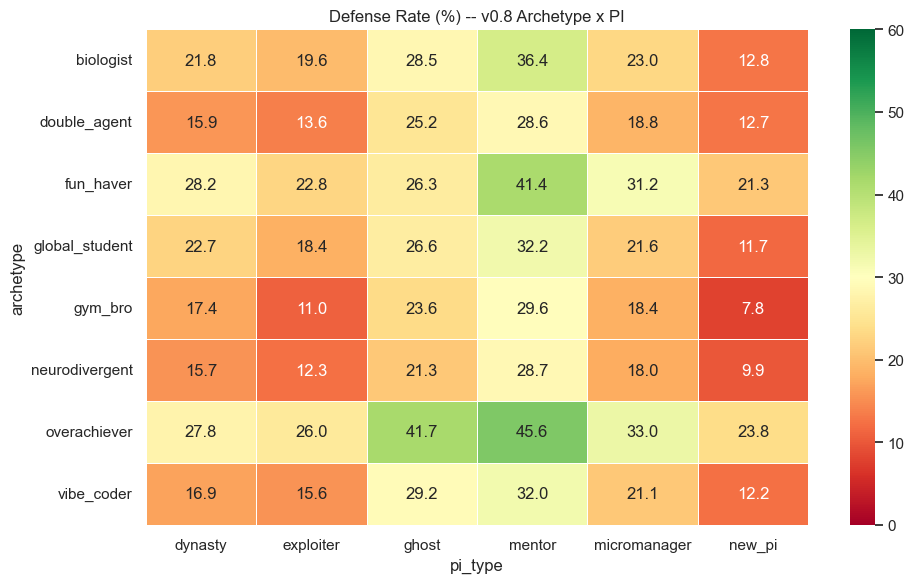

In [4]:
# Defense rate by archetype x PI
pivot = df.pivot_table(values='defended', index='archetype', columns='pi_type', aggfunc='mean').mul(100).round(1)
pivot['ALL'] = df.groupby('archetype')['defended'].mean().mul(100).round(1)

print("=== Defense Rate (%) -- Archetype x PI ===")
print(pivot.to_string())

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot.drop(columns='ALL'), annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=60, ax=ax, linewidths=0.5)
    ax.set_title('Defense Rate (%) -- v0.8 Archetype x PI')
    plt.tight_layout(); plt.show()

## 5. Balance Summary

BALANCE SUMMARY -- v0.8

Overall defense rate: 22.9%  (target: 20-60% per archetype)

Archetype defense rates:
  [OK] overachiever          33.0%  ################
  [OK] fun_haver             28.5%  ##############
  [OK] biologist             23.7%  ###########
  [OK] global_student        22.2%  ###########
  [OK] vibe_coder            21.2%  ##########
  [WARN] double_agent          19.1%  #########
  [WARN] gym_bro               18.0%  #########
  [WARN] neurodivergent        17.7%  ########

PI defense rates:
  [OK] mentor                34.3%
  [OK] ghost                 27.8%
  [OK] micromanager          23.1%
  [OK] dynasty               20.8%
  [OK] exploiter             17.4%
  [OK] new_pi                14.0%

Best  combo: ('overachiever', 'mentor')  -> 45.6%
Worst combo: ('gym_bro', 'new_pi') -> 7.8%
Spread:      37.8 pp  (target: <= 20pp)

Death causes:
  burnt_out           : 57.3%
  hospitalized        : 26.6%
  disappeared         : 9.6%
  broke               : 3.6%
  m

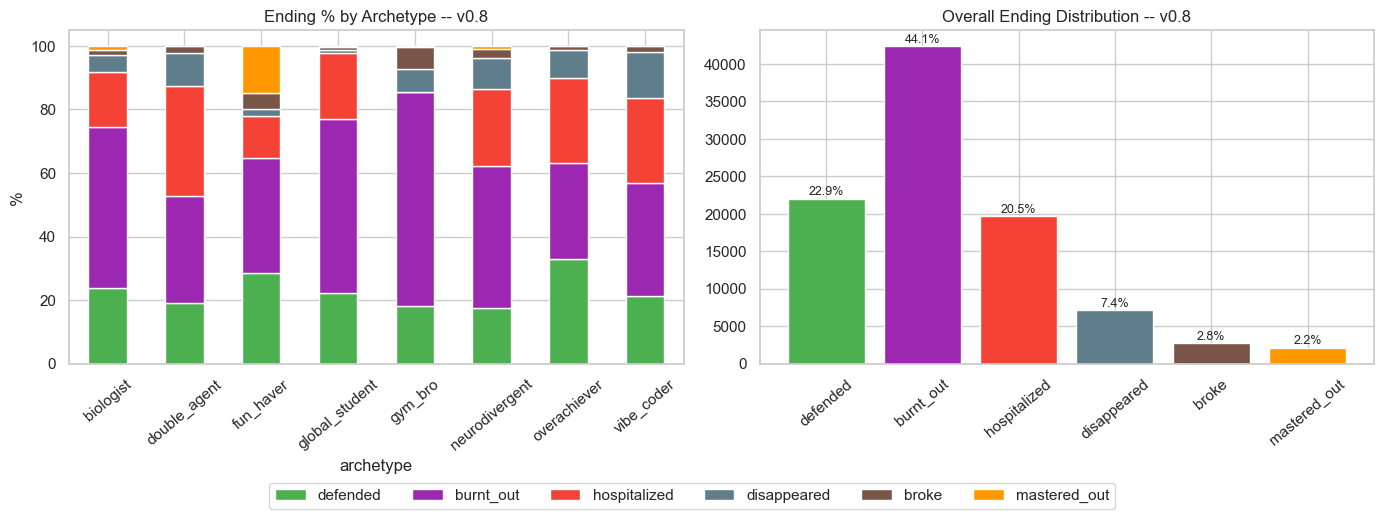

In [5]:
print("=" * 60)
print("BALANCE SUMMARY -- v0.8")
print("=" * 60)

overall = df['defended'].mean() * 100
print(f"\nOverall defense rate: {overall:.1f}%  (target: 20-60% per archetype)")

arch_rate = df.groupby('archetype')['defended'].mean().mul(100).round(1).sort_values(ascending=False)
print("\nArchetype defense rates:")
for a, r in arch_rate.items():
    flag = "OK" if 20 <= r <= 60 else ("WARN" if r >= 17 else "FAIL")
    bar  = "#" * int(r / 2)
    print(f"  [{flag}] {a:20s} {r:5.1f}%  {bar}")

pi_rate = df.groupby('pi_type')['defended'].mean().mul(100).round(1).sort_values(ascending=False)
print("\nPI defense rates:")
for p, r in pi_rate.items():
    flag = "OK" if r >= 10 else "WARN"
    print(f"  [{flag}] {p:20s} {r:5.1f}%")

combo = df.groupby(['archetype', 'pi_type'])['defended'].mean().mul(100).round(1)
best  = combo.idxmax(); worst = combo.idxmin()
print(f"\nBest  combo: {best}  -> {combo[best]:.1f}%")
print(f"Worst combo: {worst} -> {combo[worst]:.1f}%")
print(f"Spread:      {combo[best] - combo[worst]:.1f} pp  (target: <= 20pp)")

deaths = df[df['ending'] != 'defended']
print("\nDeath causes:")
for e, c in deaths['ending'].value_counts(normalize=True).mul(100).items():
    print(f"  {e:20s}: {c:.1f}%")

in_range = sum(1 for r in arch_rate.values if 20 <= r <= 60)
print(f"\nArchetypes in 20-60% range: {in_range}/8  (target: 5+)")

if HAS_PLT:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    order = ['defended','burnt_out','hospitalized','disappeared','broke','mastered_out']
    colors = ['#4CAF50','#9C27B0','#F44336','#607D8B','#795548','#FF9800']
    by_arch = df.groupby(['archetype','ending']).size().unstack(fill_value=0)
    by_arch_pct = by_arch.div(by_arch.sum(axis=1), axis=0).mul(100).reindex(columns=order, fill_value=0)
    by_arch_pct.plot(kind='bar', stacked=True, ax=axes[0], color=colors, legend=False)
    axes[0].set_title('Ending % by Archetype -- v0.8'); axes[0].set_ylabel('%')
    axes[0].tick_params(axis='x', rotation=40)

    death_counts = df['ending'].value_counts().reindex(order, fill_value=0)
    axes[1].bar(death_counts.index, death_counts.values, color=colors)
    axes[1].set_title('Overall Ending Distribution -- v0.8')
    for i, v in enumerate(death_counts.values):
        if v: axes[1].text(i, v + len(df)*0.005, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)
    axes[1].tick_params(axis='x', rotation=40)
    fig.legend(order, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout(); plt.show()